In [12]:
import pandas as pd
import numpy as np
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import ngrams
import re

import matplotlib.pyplot as plt
import seaborn as sns

import string
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Embedding, LSTM, GRU, SimpleRNN, Dropout

import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [13]:
df = pd.read_csv('combined_data.csv')

In [14]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [15]:
df.isnull().sum()

,0
label,0
text,0


In [16]:
df['text'] = df['text'].str.lower()

In [17]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [18]:
def remove_special(text):
  return text.translate(str.maketrans('', '', string.punctuation))

df['text']  = df['text'].apply(remove_special)

In [19]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [20]:
Stops = set(stopwords.words('english'))

In [21]:
Stops

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [23]:
def remove_stopwords(text):
  return [word for word in text if word not in Stops]

df['text'] = df['text'].apply(word_tokenize)
df['text'] = df['text'].apply(remove_stopwords)

In [24]:
df['text'] = df['text'].apply(lambda x: " ".join(x))

In [25]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get medircations online qnb ikud viagra...
2,0,computer connection cnn com wednesday escapenu...
3,1,university degree obtain prosperous future mon...
4,0,thanks answers guys know checked rsync manual ...


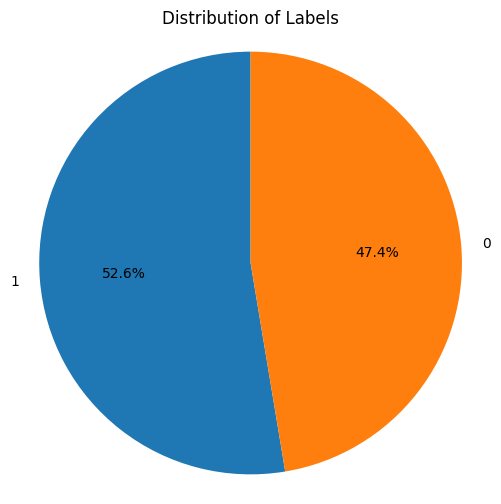

In [26]:
# To make a pie chart of the 'label' column, you can use matplotlib:
import matplotlib.pyplot as plt

# Get the counts of each label
label_counts = df['label'].value_counts()

# Create the pie chart
plt.figure(figsize=(6, 6)) # Optional: set figure size
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Distribution of Labels')
plt.show()

In [27]:
from collections import Counter

# Separate spam and ham
spam_text = " ".join(df[df['label'] == 1]['text'])
ham_text  = " ".join(df[df['label'] == 0]['text'])

# Count words
spam_counter = Counter(spam_text.split())
ham_counter = Counter(ham_text.split())

# Top 10 words
print("Top 10 Spam Words:")
print(spam_counter.most_common(10))

print("\nTop 10 Ham Words:")
print(ham_counter.most_common(10))

Top 10 Spam Words:
[('escapenumber', 333240), ('escapelong', 188104), ('com', 29001), ('http', 27756), ('per', 26141), ('x', 23821), ('pills', 23128), ('escapenumbermg', 20541), ('price', 18723), ('company', 15872)]

Top 10 Ham Words:
[('escapenumber', 799937), ('http', 54399), ('r', 53451), ('enron', 52856), ('c', 45222), ('org', 42557), ('com', 40681), ('escapelong', 39075), ('ect', 34743), ('help', 32661)]


In [28]:
print(df['text'].iloc[0])

ounce feather bowl hummingbird opec moment alabaster valkyrie dyad bread flack desperate iambic hadron heft quell yoghurt bunkmate divert afterimage


In [29]:
print(df.isnull().sum())

label    0
text     0
dtype: int64


In [30]:
print((df['text'].str.strip() == '').sum())

19


In [31]:
df = df[df['text'].str.strip() != '']

In [32]:
print(df['label'].value_counts())

label
1    43894
0    39535
Name: count, dtype: int64


In [33]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [34]:
X_train

,text
58781,dog varou average person thinks isnt father la...
32384,dear sirs aegis capital group llc aegis spec...
48230,best new dating site net check singlesnet onli...
70056,make work thanks original message kitchen loui...
43174,linda selfishly go potato swim hear ou love st...
...,...
6265,anita conversation today daren deal pops trans...
54897,want make money home tired working someone els...
76837,finding rates low enough suit never easy task ...
860,alternative medicine database escapenumber mil...


In [35]:
max_features = 5000
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [36]:
X_test_seq

[[566,
  79,
  1661,
  100,
  1131,
  4514,
  57,
  2748,
  1131,
  3,
  11,
  2489,
  4,
  1096,
  2375,
  1,
  2259,
  1043,
  88,
  266,
  1,
  1,
  212,
  1626,
  3,
  11,
  2489,
  4,
  1096,
  2375,
  1,
  42,
  2837,
  3,
  11,
  2489,
  4,
  1096,
  3245,
  1,
  394,
  2489,
  4368,
  3,
  11,
  2489,
  4,
  1096,
  824,
  454,
  1368,
  92,
  2443,
  2489,
  339,
  359,
  38,
  2718,
  2489,
  829,
  74,
  4669,
  2489,
  32,
  536,
  682,
  494,
  218,
  1274,
  3546,
  11,
  2489,
  4,
  97,
  487,
  829,
  38,
  2753,
  611,
  2489,
  829,
  723,
  1898,
  2540,
  1215,
  1467,
  2489,
  1274,
  312,
  65,
  528,
  605,
  829,
  11,
  2489,
  4,
  2489,
  120,
  1,
  2873,
  2511,
  1,
  363,
  1,
  1,
  1,
  1],
 [194,
  1537,
  1047,
  789,
  21,
  2249,
  1042,
  2005,
  115,
  74,
  130,
  23,
  714,
  3,
  4,
  64,
  36,
  3476,
  27,
  880,
  80,
  959,
  3850,
  3226],
 [1142,
  623,
  1,
  1,
  1,
  1,
  3213,
  1,
  3958,
  86,
  243,
  631,
  50,
  33,
  302,
  35

In [37]:
average_length = sum(map(len, X_train_seq)) / len(X_train_seq)
print("Average length of text sequences:", average_length)

Average length of text sequences: 141.30557990589836


In [38]:
max_length = 500
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length,padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length,padding='post')

In [39]:
X_train_pad

array([[2999, 1212,  514, ...,    0,    0,    0],
       [ 236, 4997, 4972, ...,    0,    0,    0],
       [  92,   12, 4721, ...,    0,    0,    0],
       ...,
       [2233, 1172,  106, ...,    0,    0,    0],
       [ 673, 2287,  565, ...,    0,    0,    0],
       [ 678,  217,   37, ...,    0,    0,    0]], dtype=int32)

In [40]:
max_features = 5000
max_length = 500
embedding_length = 32

In [41]:
model_rnn = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),

    SimpleRNN(64),

    Dense(1, activation='sigmoid')
])

model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_rnn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
model_lstm = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),
    LSTM(64, use_cudnn=False),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
model_gru = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),

    GRU(64,use_cudnn=False),

    Dense(1, activation='sigmoid')
])

model_gru.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [44]:
EPOCHS = 10
BATCH_SIZE = 64

In [45]:
history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 43s 44ms/step - accuracy: 0.9479 - loss: 0.1439 - val_accuracy: 0.9777 - val_loss: 0.0732
Epoch 2/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.9832 - loss: 0.0563 - val_accuracy: 0.9501 - val_loss: 0.1659
Epoch 3/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.9827 - loss: 0.0569 - val_accuracy: 0.9797 - val_loss: 0.0679
Epoch 4/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.9919 - loss: 0.0289 - val_accuracy: 0.9789 - val_loss: 0.0764
Epoch 5/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.9826 - loss: 0.0499 - val_accuracy: 0.9380 - val_loss: 0.1597
Epoch 6/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.9826 - loss: 0.0484 - val_accuracy: 0.9707 - val_loss: 0.1036
Epoch 7/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.9796 - loss: 0.0587 - val_accuracy: 0.9748 - val_loss: 0.0855
Epoch 8/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.9929 - loss: 0.0249 - 

In [46]:
import numpy as np

y_pred_prob = model_rnn.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

861/861 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step


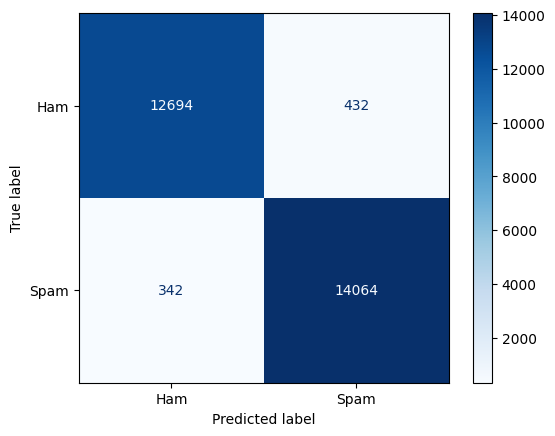

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
)
disp.plot(cmap='Blues')
plt.show()


In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97     13126
           1       0.97      0.98      0.97     14406

    accuracy                           0.97     27532
   macro avg       0.97      0.97      0.97     27532
weighted avg       0.97      0.97      0.97     27532



In [49]:
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.9604 - loss: 0.1222 - val_accuracy: 0.9553 - val_loss: 0.1545
Epoch 2/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9790 - loss: 0.0674 - val_accuracy: 0.9803 - val_loss: 0.0666
Epoch 3/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.9887 - loss: 0.0374 - val_accuracy: 0.9824 - val_loss: 0.0521
Epoch 4/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.9899 - loss: 0.0332 - val_accuracy: 0.9778 - val_loss: 0.0658
Epoch 5/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9907 - loss: 0.0333 - val_accuracy: 0.9828 - val_loss: 0.0569
Epoch 6/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9928 - loss: 0.0256 - val_accuracy: 0.9829 - val_loss: 0.0573
Epoch 7/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9935 - loss: 0.0224 - val_accuracy: 0.9825 - val_loss: 0.0631
Epoch 8/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9944 - loss: 0.0201 - 

In [50]:
history_gru = model_gru.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 57s 59ms/step - accuracy: 0.9619 - loss: 0.1089 - val_accuracy: 0.9758 - val_loss: 0.0770
Epoch 2/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 76s 55ms/step - accuracy: 0.9873 - loss: 0.0424 - val_accuracy: 0.9829 - val_loss: 0.0509
Epoch 3/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9902 - loss: 0.0352 - val_accuracy: 0.9848 - val_loss: 0.0492
Epoch 4/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9931 - loss: 0.0244 - val_accuracy: 0.9736 - val_loss: 0.0985
Epoch 5/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 52s 60ms/step - accuracy: 0.9948 - loss: 0.0201 - val_accuracy: 0.9839 - val_loss: 0.0512
Epoch 6/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 48s 54ms/step - accuracy: 0.9939 - loss: 0.0215 - val_accuracy: 0.9837 - val_loss: 0.0523
Epoch 7/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 49s 56ms/step - accuracy: 0.9970 - loss: 0.0117 - val_accuracy: 0.9837 - val_loss: 0.0581
Epoch 8/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9970 - loss: 0.0101 - 

In [51]:
import numpy as np

y_pred_prob_lstm = model_lstm.predict(X_test_pad)
y_pred_lstm = (y_pred_prob_lstm > 0.5).astype(int)

861/861 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step


In [52]:
from sklearn.metrics import accuracy_score

lstm_accuracy = accuracy_score(y_test, y_pred_lstm)
print("LSTM Accuracy:", lstm_accuracy)

LSTM Accuracy: 0.9831468836263257


In [53]:
from sklearn.metrics import classification_report

print("LSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=["Ham", "Spam"]))

LSTM Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.98     13126
        Spam       0.98      0.99      0.98     14406

    accuracy                           0.98     27532
   macro avg       0.98      0.98      0.98     27532
weighted avg       0.98      0.98      0.98     27532



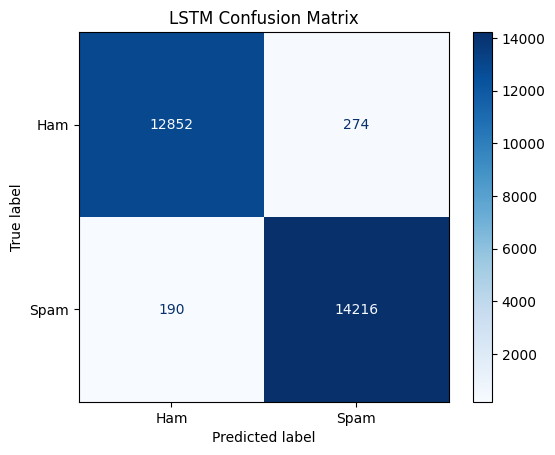

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lstm = confusion_matrix(y_test, y_pred_lstm)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=["Ham", "Spam"]
).plot(cmap="Blues")

plt.title("LSTM Confusion Matrix")
plt.show()

In [55]:
y_pred_prob_gru = model_gru.predict(X_test_pad)
y_pred_gru = (y_pred_prob_gru > 0.5).astype(int)

861/861 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step


In [56]:
gru_accuracy = accuracy_score(y_test, y_pred_gru)
print("GRU Accuracy:", gru_accuracy)


GRU Accuracy: 0.982202527967456


In [57]:
print("GRU Classification Report:")
print(classification_report(y_test, y_pred_gru, target_names=["Ham", "Spam"]))


GRU Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.98      0.98     13126
        Spam       0.98      0.98      0.98     14406

    accuracy                           0.98     27532
   macro avg       0.98      0.98      0.98     27532
weighted avg       0.98      0.98      0.98     27532



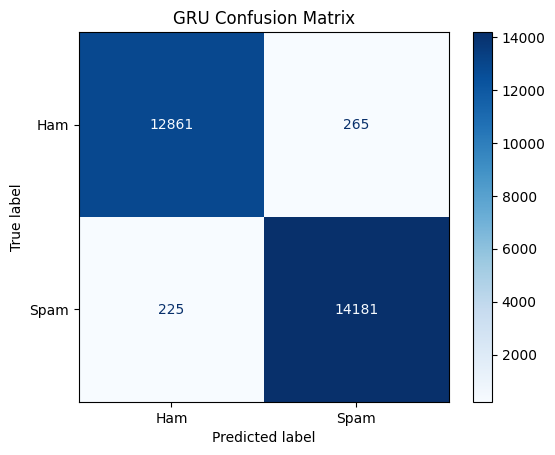

In [58]:
cm_gru = confusion_matrix(y_test, y_pred_gru)

ConfusionMatrixDisplay(
    confusion_matrix=cm_gru,
    display_labels=["Ham", "Spam"]
).plot(cmap="Blues")

plt.title("GRU Confusion Matrix")
plt.show()

In [59]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

def evaluate_model(model, X_test, y_test, model_name):
    y_prob = model.predict(X_test)
    y_pred = (y_prob > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Spam Precision": report["1"]["precision"],
        "Spam Recall": report["1"]["recall"],
        "Spam F1": report["1"]["f1-score"]
    }


In [60]:
results = []

results.append(evaluate_model(model_rnn, X_test_pad, y_test, "Simple RNN"))
results.append(evaluate_model(model_lstm, X_test_pad, y_test, "LSTM"))
results.append(evaluate_model(model_gru, X_test_pad, y_test, "GRU"))

results_df = pd.DataFrame(results)
print(results_df)


861/861 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
861/861 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step
861/861 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
        Model  Accuracy  Spam Precision  Spam Recall   Spam F1
0  Simple RNN  0.971887        0.970199     0.976260  0.973220
1        LSTM  0.983147        0.981090     0.986811  0.983942
2         GRU  0.982203        0.981656     0.984382  0.983017


In [61]:
best_model_row = results_df.sort_values(
    by="Spam F1",
    ascending=False
).iloc[0]

print("Best Model:")
print(best_model_row)


Best Model:
Model                 LSTM
Accuracy          0.983147
Spam Precision     0.98109
Spam Recall       0.986811
Spam F1           0.983942
Name: 1, dtype: object


In [62]:
model_gru.save("gru_model.keras")

In [63]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [64]:
config = {
    "max_features": max_features,
    "max_length": max_length,
    "embedding_length": embedding_length
}

with open("config.pkl", "wb") as f:
    pickle.dump(config, f)

In [65]:
label_mapping = {0: "Ham", 1: "Spam"}

with open("label_mapping.pkl", "wb") as f:
    pickle.dump(label_mapping, f)